In [1]:
import numpy as np
import pandas as pd
import os
import random
import json
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

In [2]:
X_PCA_PATH = "/kaggle/input/gene-preprocess-ade949/saved_model/X_pca.npy"

OUTPUT_DIR = "/kaggle/working/"
OUTPUT_DIR_MODEL = os.path.join(OUTPUT_DIR, "kmeans_results")
os.makedirs(OUTPUT_DIR_MODEL, exist_ok=True)

OUTPUT_DIR_ENSEMBLE = os.path.join(OUTPUT_DIR, "kmeans_ensemble")
os.makedirs(OUTPUT_DIR_ENSEMBLE, exist_ok=True)

In [3]:
X_pca = np.load(X_PCA_PATH)
print("X_pca shape:", X_pca.shape)

X_pca shape: (111, 10)


In [4]:
k_range = range(2, 20)

results = {
    'k': [],
    'silhouette': [],
    'inertia': [],
    'labels': []
}

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=50,
        max_iter=500,
        random_state=57
    )
    
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    
    results['k'].append(k)
    results['silhouette'].append(score)
    results['inertia'].append(kmeans.inertia_)
    results['labels'].append(labels)
    
    print(f"k={k} | silhouette={score}")

k=2 | silhouette=0.3435754584831953
k=3 | silhouette=0.2566714612896142
k=4 | silhouette=0.2747363644947144
k=5 | silhouette=0.2552275191336517
k=6 | silhouette=0.27591181772173146
k=7 | silhouette=0.2955132698493282
k=8 | silhouette=0.296283554522947
k=9 | silhouette=0.3016869588008823
k=10 | silhouette=0.31511894781619776
k=11 | silhouette=0.31824842522804847
k=12 | silhouette=0.32145486077882246
k=13 | silhouette=0.32259414251358404
k=14 | silhouette=0.3178921770530171
k=15 | silhouette=0.31888614788814884
k=16 | silhouette=0.274752461241644
k=17 | silhouette=0.25921126636108555
k=18 | silhouette=0.2626061972456761
k=19 | silhouette=0.2338927531502652


In [5]:
df_results = pd.DataFrame(results)
df_results.head()

,k,silhouette,inertia,labels
0,2,0.343575,1.095138e+06,"[0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, ..."
1,3,0.256671,9.548552e+05,"[0, 0, 1, 0, 2, 2, 1, 1, 1, 0, 1, 0, 0, 0, 0, ..."
2,4,0.274736,8.149062e+05,"[2, 2, 0, 2, 1, 1, 0, 0, 0, 2, 0, 2, 2, 2, 2, ..."
3,5,0.255228,6.951719e+05,"[1, 0, 2, 0, 3, 3, 2, 2, 2, 0, 2, 1, 1, 1, 0, ..."
4,6,0.275912,6.135242e+05,"[2, 0, 1, 0, 2, 4, 1, 1, 1, 0, 1, 2, 2, 2, 0, ..."


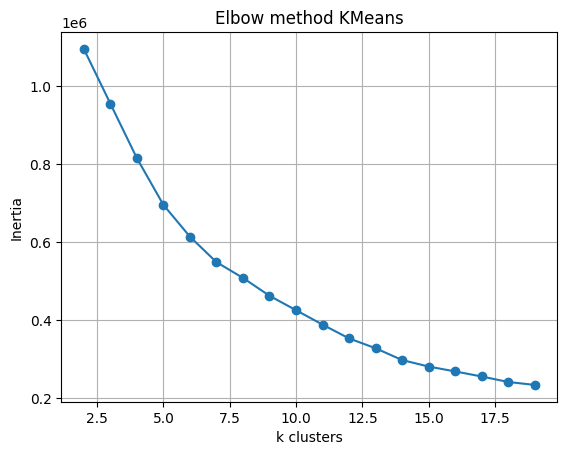

In [6]:
plt.plot(df_results["k"], df_results["inertia"], marker="o")
plt.xlabel("k clusters")
plt.ylabel("Inertia")
plt.title("Elbow method KMeans")
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR_MODEL, "kmeans_elbow.png"))
plt.show()

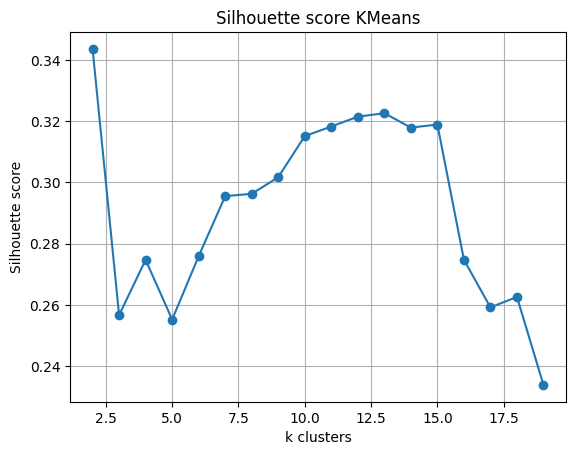

In [7]:
plt.plot(df_results["k"], df_results["silhouette"], marker="o")
plt.xlabel("k clusters")
plt.ylabel("Silhouette score")
plt.title("Silhouette score KMeans")
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR_MODEL, "kmeans_silhouette.png"))
plt.show()

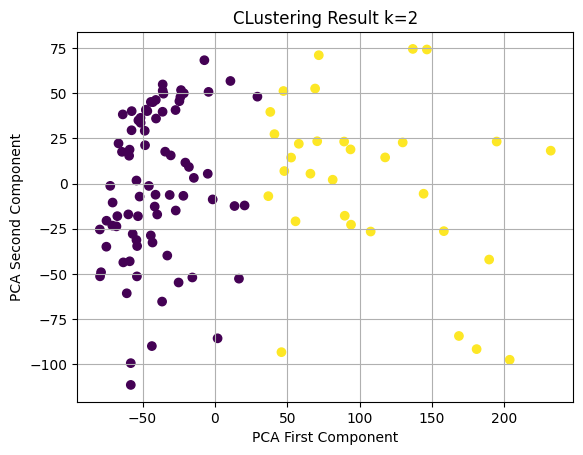

In [8]:
k = 2
row_index = k-2
df_label = df_results['labels'][row_index]

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_label)
plt.xlabel("PCA First Component")
plt.ylabel("PCA Second Component")
plt.title(f"CLustering Result k={k}")
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR_MODEL, "kmeans_clustering.png"))
plt.show()

In [9]:
k = 20
n_runs = 128
n_compares = n_runs*2

all_labels = []

In [10]:
for i in range(n_runs):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=1
    )
    labels = kmeans.fit_predict(X_pca)
    all_labels.append(labels)

In [11]:
ari_scores = []

for _ in range(n_compares):
    i, j = random.sample(range(n_runs), 2)
    ari = adjusted_rand_score(all_labels[i], all_labels[j])
    ari_scores.append(ari)

ari_scores = np.array(ari_scores)

ARI mean: 0.6318139628651986
ARI std: 0.08937687058282238
ARI min: 0.4386067740609662
ARI max: 0.8937925816840095


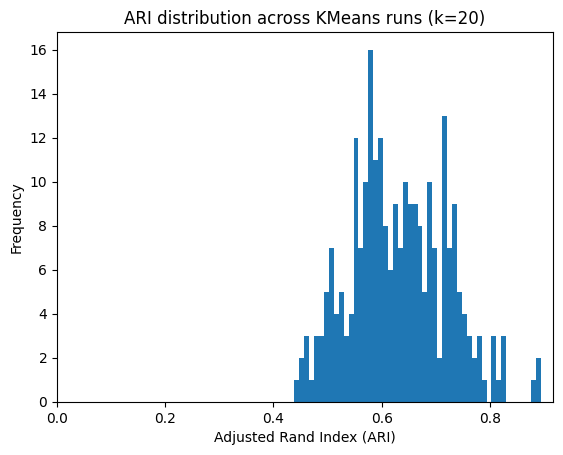

In [12]:
plt.hist(ari_scores, bins=50)
plt.xlabel("Adjusted Rand Index (ARI)")
plt.xticks(np.arange(0, 1, step=0.2))
plt.ylabel("Frequency")
plt.title(f"ARI distribution across KMeans runs (k={k})")

print(f"ARI mean: {ari_scores.mean()}")
print(f"ARI std: {ari_scores.std()}")
print(f"ARI min: {ari_scores.min()}")
print(f"ARI max: {ari_scores.max()}")

plt.savefig(os.path.join(OUTPUT_DIR_ENSEMBLE, "kmeans_ensemble_ari.png"))
plt.show()

In [13]:
import pickle
path = os.path.join(OUTPUT_DIR_MODEL, "kmeans_all_results.csv")
df_results.to_csv(path, index=False)
# 2. Save model
with open(os.path.join(OUTPUT_DIR_MODEL, "kmeans.pkl"), "wb") as f:
    pickle.dump(kmeans, f)

path = os.path.join(OUTPUT_DIR_MODEL, "kmeans_config.json")
config = {
    'k': 3,
    'init': "k-means++",
    'n_init': 50,
    'max_iter': 500
}
with open(path, "w") as f:
    json.dump(config, f)

path = os.path.join(OUTPUT_DIR_MODEL, "kmeans_labels.npy")
np.save(path, df_results['labels'][row_index])

In [14]:
path = os.path.join(OUTPUT_DIR_ENSEMBLE, "kmeans_ensemble_labels.npy")
labels_array = np.stack(all_labels)

np.save(path, labels_array)

path = os.path.join(OUTPUT_DIR_ENSEMBLE, "kmeans_ensemble_config.npy")
config = {
    'k': 20,
    'init': "k-means++",
    'n_runs': 128,
}
with open(path, "w") as f:
    json.dump(config, f)